# Energy Consumption Forecasting

In this project, we want to predict energy consumption using several forecasting models.

The dataset contains 1,000 hourly observations of building energy consumption. Each record includes weather conditions, building characteristics, occupancy, HVAC and lighting usage, renewable energy generation, holiday status, and observed energy consumption. Because the data is hourly, the forecasting workflow uses time-based features, daily and weekly seasonality, lagged consumption, rolling averages, and weather-related predictors.

### Import Libraries

In [39]:
import kagglehub
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

### Import data

In [59]:
# 1. Download the dataset
path = kagglehub.dataset_download("mrsimple07/energy-consumption-prediction")
print("Dataset downloaded to:", path)

# 2. List files to find the exact CSV filename
files = os.listdir(path)
print("Files in directory:", files)

# 3. Load and view the data
csv_path = os.path.join(path, "Energy_consumption.csv") 
df = pd.read_csv(csv_path)

# 4. Display the first 5 rows
df.head()

Dataset downloaded to: /Users/shaiguides/.cache/kagglehub/datasets/mrsimple07/energy-consumption-prediction/versions/1
Files in directory: ['Energy_consumption.csv']


,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


### Data Cleaning

In [22]:
df.describe()

,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.982026,45.395412,1500.052488,4.581000,15.132813,77.055873
std,2.836850,8.518905,288.418873,2.865598,8.745917,8.144112
min,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,22.645070,38.297722,1247.108548,2.000000,7.628385,71.544690
50%,24.751637,45.972116,1507.967426,5.000000,15.072296,76.943696
75%,27.418174,52.420066,1740.340165,7.000000,22.884064,82.921742
max,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   str    
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   str    
 6   LightingUsage      1000 non-null   str    
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   str    
 9   Holiday            1000 non-null   str    
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 118.9 KB


In [24]:
# Check if data is hourly
print(df.index.to_series().diff().value_counts().head())

1.0    999
Name: count, dtype: int64


In [25]:
# Convert 'Timestamp' to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df = (df.sort_values("Timestamp")
      .set_index("Timestamp")
      .asfreq("h")
)

df.isna().sum()

Temperature          0
Humidity             0
SquareFootage        0
Occupancy            0
HVACUsage            0
LightingUsage        0
RenewableEnergy      0
DayOfWeek            0
Holiday              0
EnergyConsumption    0
dtype: int64

### Create time features

In [27]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["day"] = df.index.day
df["month"] = df.index.month
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

### Create lag features

In [28]:
df["lag_1"] = df["EnergyConsumption"].shift(1)
df["lag_24"] = df["EnergyConsumption"].shift(24)
df["lag_168"] = df["EnergyConsumption"].shift(168)

df["rolling_24"] = df["EnergyConsumption"].shift(1).rolling(24).mean()

df = df.dropna()

### Encoding Categorical Variables

In [30]:
categorical_cols = [
    "HVACUsage",
    "LightingUsage",
    "DayOfWeek",
    "Holiday"
]

df_model = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

### Daily averages and rolling averages

A raw hourly line plot can look noisy.

In [32]:
# Energy and renewable energy are usually totals, while temperature and humidity are usually averages
daily_df = df.resample("D").agg({
    "EnergyConsumption": "sum",
    "Temperature": "mean",
    "Humidity": "mean",
    "Occupancy": "mean",
    "RenewableEnergy": "sum"
})

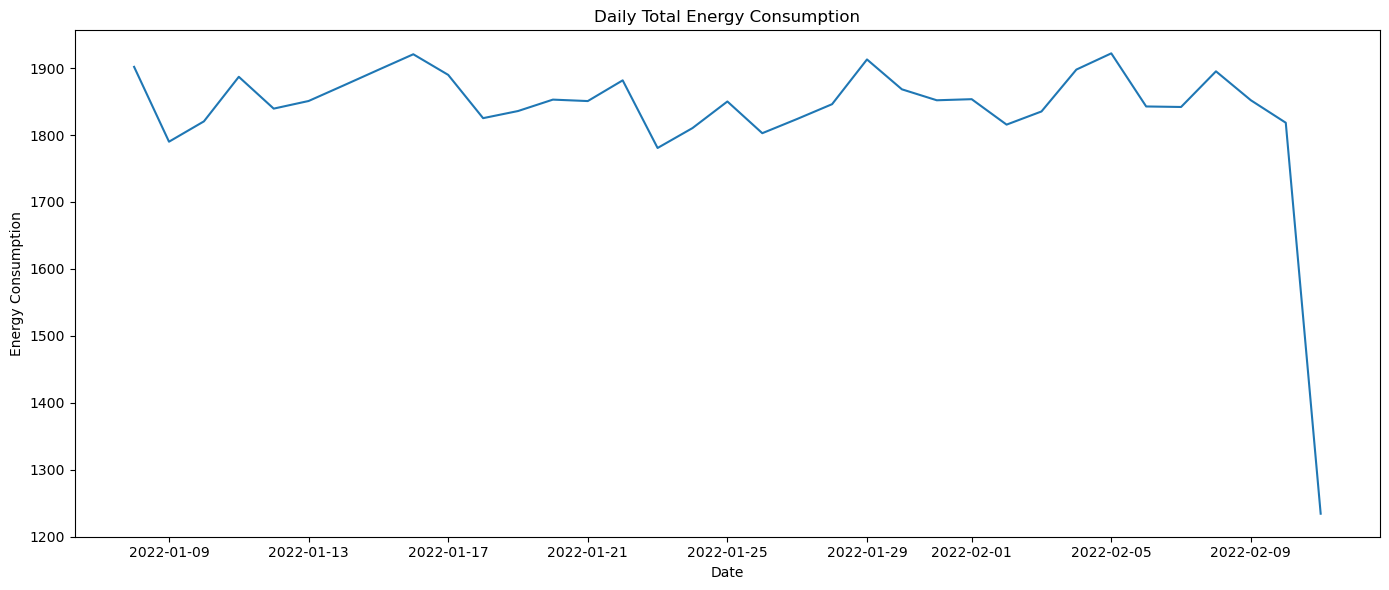

In [33]:
# Daily Average from hourly
plt.figure(figsize=(14, 6))
plt.plot(daily_df.index, daily_df["EnergyConsumption"])
plt.title("Daily Total Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.tight_layout()
plt.show()

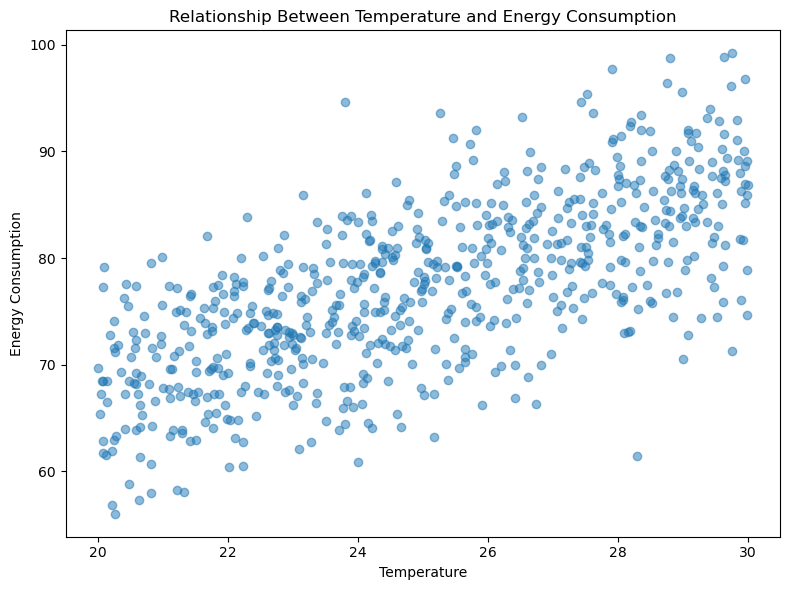

In [56]:
# Scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Temperature"],
    df["EnergyConsumption"],
    alpha=0.5
)

plt.title("Relationship Between Temperature and Energy Consumption")
plt.xlabel("Temperature")
plt.ylabel("Energy Consumption")
plt.tight_layout()
plt.show()

In [57]:
corr = df["Temperature"].corr(df["EnergyConsumption"])
print(f"Correlation between temperature and energy consumption: {corr:.3f}")

Correlation between temperature and energy consumption: 0.690


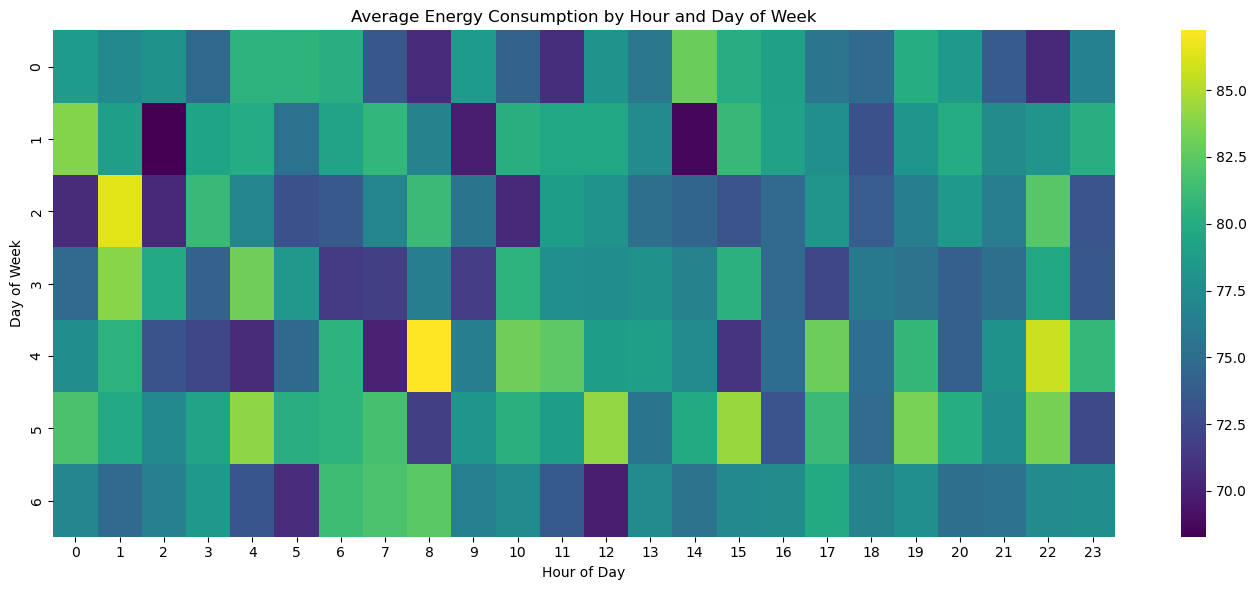

In [36]:
# Heatmap by hour and day of week
heatmap_data = df.pivot_table(
    values="EnergyConsumption",
    index="dayofweek",
    columns="hour",
    aggfunc="mean"
)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="viridis")
plt.title("Average Energy Consumption by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

### Test for Stationarity

- But not using ARIMA, etc

In [61]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df["EnergyConsumption"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("The series is likely stationary.")
else:
    print("The series is likely non-stationary.")

ADF Statistic: -31.576934146718372
p-value: 0.0
The series is likely stationary.


### Train/test split for hourly forecasting

Since this is time series data, do not use random split.

In [37]:
target = "EnergyConsumption"

X = df_model.drop(columns=[target])
y = df_model[target]

split_point = int(len(df_model) * 0.8)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]

y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (665, 23)
Test size: (167, 23)


### Good baseline models

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_forecast(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

forecast_results = []

# Same hour yesterday
baseline_24_preds = X_test["lag_24"]

forecast_results.append(
    evaluate_forecast(
        "Same Hour Yesterday",
        y_test,
        baseline_24_preds
    )
)

pd.DataFrame(forecast_results)

,model,MAE,RMSE,MAPE,R2
0,Same Hour Yesterday,9.098986,11.161816,11.81835,-1.089826


Poor baseline result because energy consumption depends on more than yesterday’s value.

## Machine learning models

### Random Forest

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

forecast_results.append(
    evaluate_forecast(
        "Random Forest",
        y_test,
        rf_preds
    )
)

pd.DataFrame(forecast_results).sort_values("MAPE")

,model,MAE,RMSE,MAPE,R2
1,Random Forest,4.136175,4.935858,5.351256,0.591337
0,Same Hour Yesterday,9.098986,11.161816,11.818350,-1.089826


### Feature Importance

In [43]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
0,Temperature,0.522915
3,Occupancy,0.063293
14,HVACUsage_On,0.059965
1,Humidity,0.041214
4,RenewableEnergy,0.039578
2,SquareFootage,0.036374
12,lag_168,0.035396
10,lag_1,0.035391
7,day,0.031308
11,lag_24,0.029902


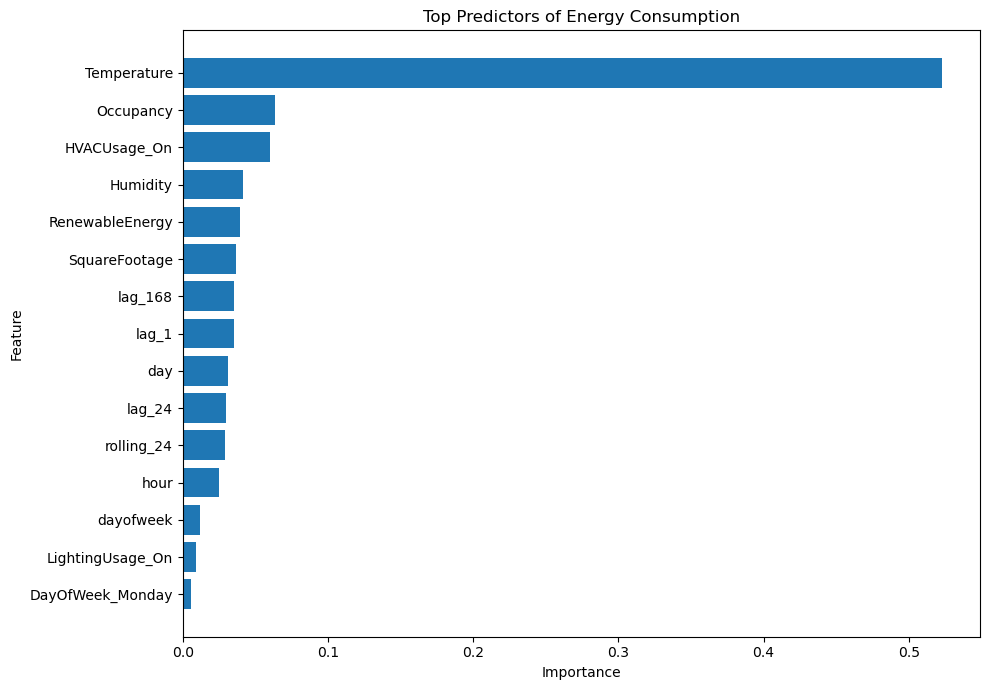

In [44]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance.head(15)["feature"],
    feature_importance.head(15)["importance"]
)

plt.gca().invert_yaxis()
plt.title("Top Predictors of Energy Consumption")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Prophet model without Regressors

Prophet can handle hourly data, but use daily and weekly seasonality.

In [45]:
from prophet import Prophet

prophet_df = df.reset_index()[["Timestamp", "EnergyConsumption"]]

prophet_df = prophet_df.rename(columns={
    "Timestamp": "ds",
    "EnergyConsumption": "y"
})

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(
    periods=24 * 7,
    freq="h"
)

prophet_forecast = prophet_model.predict(future)

prophet_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

00:24:50 - cmdstanpy - INFO - Chain [1] start processing
00:24:50 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
995,2022-02-18 11:00:00,78.413884,68.306254,89.028630
996,2022-02-18 12:00:00,78.717358,69.095956,89.504060
997,2022-02-18 13:00:00,78.720942,68.899976,87.891879
998,2022-02-18 14:00:00,78.572811,68.405787,89.571287
999,2022-02-18 15:00:00,78.530443,68.350437,88.350292


In [47]:
# Comparing with other models
# Prepare Prophet training data
prophet_train = pd.DataFrame({
    "ds": y_train.index,
    "y": y_train.values
})

# Prepare Prophet test dates
prophet_test = pd.DataFrame({
    "ds": y_test.index
})

# Fit Prophet model
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

prophet_model.fit(prophet_train)

# Forecast test period
prophet_forecast = prophet_model.predict(prophet_test)

prophet_preds = prophet_forecast["yhat"].values

# Add Prophet result to forecast_results
forecast_results.append(
    evaluate_forecast(
        "Prophet",
        y_test,
        prophet_preds
    )
)

# View all model results
pd.DataFrame(forecast_results).sort_values("MAPE")

00:28:03 - cmdstanpy - INFO - Chain [1] start processing
00:28:03 - cmdstanpy - INFO - Chain [1] done processing


,model,MAE,RMSE,MAPE,R2
1,Random Forest,4.136175,4.935858,5.351256,0.591337
2,Prophet,6.211482,7.708153,7.990514,0.003354
0,Same Hour Yesterday,9.098986,11.161816,11.818350,-1.089826


In [48]:
# model_comparison = pd.DataFrame(forecast_results).sort_values("MAPE")

# model_comparison.to_csv(
#     "outputs/model_comparison.csv",
#     index=False
# )

# model_comparison

### Improving the models

In [50]:
df.head()

,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption,...,dayofweek,day,month,is_weekend,lag_1,lag_24,lag_168,rolling_24,hour_sin,hour_cos
Timestamp,,,,,,,,,,,,,,,,,,,,,
2022-01-08 00:00:00,25.714735,42.298665,1999.204208,1,On,On,29.565863,Saturday,No,75.614982,...,5,8,1,1,72.890584,74.179044,75.364373,78.266218,0.000000,1.000000
2022-01-08 01:00:00,20.914792,31.710094,1486.780868,5,Off,On,4.306860,Friday,No,71.789647,...,5,8,1,1,75.614982,69.915141,83.401855,78.326048,0.258819,0.965926
2022-01-08 02:00:00,25.205341,48.649901,1533.208172,3,Off,Off,4.054743,Wednesday,No,63.008158,...,5,8,1,1,71.789647,91.594355,78.270888,78.404153,0.500000,0.866025
2022-01-08 03:00:00,25.976524,38.484153,1595.427693,4,On,On,16.205204,Tuesday,No,94.550625,...,5,8,1,1,63.008158,76.138955,56.519850,77.213061,0.707107,0.707107
2022-01-08 04:00:00,27.726414,53.339179,1751.722623,2,On,Off,21.647358,Wednesday,Yes,83.576831,...,5,8,1,1,94.550625,70.976913,70.811732,77.980214,0.866025,0.500000


In [51]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

In [52]:
df["lag_1"] = df["EnergyConsumption"].shift(1)
df["lag_2"] = df["EnergyConsumption"].shift(2)
df["lag_3"] = df["EnergyConsumption"].shift(3)
df["lag_24"] = df["EnergyConsumption"].shift(24)
df["lag_48"] = df["EnergyConsumption"].shift(48)
df["lag_168"] = df["EnergyConsumption"].shift(168)

df["rolling_3"] = df["EnergyConsumption"].shift(1).rolling(3).mean()
df["rolling_6"] = df["EnergyConsumption"].shift(1).rolling(6).mean()
df["rolling_24"] = df["EnergyConsumption"].shift(1).rolling(24).mean()
df["rolling_168"] = df["EnergyConsumption"].shift(1).rolling(168).mean()

df = df.dropna()

In [53]:
categorical_cols = [
    "HVACUsage",
    "LightingUsage",
    "DayOfWeek",
    "Holiday"
]

df_model = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [54]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

forecast_results.append(
    evaluate_forecast(
        "Improved Random Forest",
        y_test,
        rf_preds
    )
)

pd.DataFrame(forecast_results).sort_values("MAPE")

,model,MAE,RMSE,MAPE,R2
3,Improved Random Forest,4.054653,4.867579,5.236874,0.602565
1,Random Forest,4.136175,4.935858,5.351256,0.591337
2,Prophet,6.211482,7.708153,7.990514,0.003354
0,Same Hour Yesterday,9.098986,11.161816,11.818350,-1.089826


In [55]:
prophet_data = df.reset_index()[[
    "Timestamp",
    "EnergyConsumption",
    "Temperature",
    "Humidity",
    "SquareFootage",
    "Occupancy",
    "RenewableEnergy"
]].rename(columns={
    "Timestamp": "ds",
    "EnergyConsumption": "y"
})

split_point = int(len(prophet_data) * 0.8)

prophet_train = prophet_data.iloc[:split_point]
prophet_test = prophet_data.iloc[split_point:]

prophet_reg_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

regressors = [
    "Temperature",
    "Humidity",
    "SquareFootage",
    "Occupancy",
    "RenewableEnergy"
]

for col in regressors:
    prophet_reg_model.add_regressor(col)

prophet_reg_model.fit(prophet_train)

prophet_future_test = prophet_test[["ds"] + regressors]

prophet_reg_forecast = prophet_reg_model.predict(prophet_future_test)

prophet_reg_preds = prophet_reg_forecast["yhat"].values

forecast_results.append(
    evaluate_forecast(
        "Prophet with Regressors",
        prophet_test["y"],
        prophet_reg_preds
    )
)

pd.DataFrame(forecast_results).sort_values("MAPE")

00:32:19 - cmdstanpy - INFO - Chain [1] start processing
00:32:19 - cmdstanpy - INFO - Chain [1] done processing


,model,MAE,RMSE,MAPE,R2
3,Improved Random Forest,4.054653,4.867579,5.236874,0.602565
1,Random Forest,4.136175,4.935858,5.351256,0.591337
4,Prophet with Regressors,4.528273,5.565463,5.918722,0.463751
2,Prophet,6.211482,7.708153,7.990514,0.003354
0,Same Hour Yesterday,9.098986,11.161816,11.818350,-1.089826


#### Meaning of the result:

- Same Hour Yesterday performs poorly because yesterday’s same hour alone does not explain energy use.
- Plain Prophet performs weakly because it only sees time patterns, not building/weather/usage variables.
- Prophet with Regressors improves because it uses predictors like temperature, humidity, occupancy, and renewable energy.
- Random Forest performs best because it can capture nonlinear relationships between temperature, occupancy, HVAC usage, lighting usage, lags, and energy consumption.

The result tells a clear story: energy consumption is better predicted using weather, occupancy, usage behavior, and lagged consumption than by time patterns alone.